In [1]:
import numpy as np
import pandas as pd
import scipy
import scipy.stats
import matplotlib as mpl   
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import t, norm

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [2]:
def get_stock_data(ticker, max, start_date, end_date):
    try:
        # https://medium.com/nerd-for-tech/all-you-need-to-know-about-yfinance-yahoo-finance-library-fa4c6e48f08e
        data = yf.Ticker(ticker)
        if max == False:
            data = data.history(start=start_date, end=end_date)
        else:
            data = data.history(period="max")
        return data
    except Exception as e:
        return f"Error fetching data: {e}"

In [3]:
#demo index
stock_data = get_stock_data("PREIX", False,"2000-01-01", "2024-10-01")
stock_data.asfreq('B').index  # set index frequency to business daliy
stock_data['Daily Return'] = stock_data['Close'].pct_change()  # percentage return

In [4]:
#simple threshold determination (based on SD, mean, etc. -- to be experimented with)

mean_return = stock_data['Daily Return'].mean()
std_return = stock_data['Daily Return'].std()

# Define thresholds
up_threshold = mean_return + std_return
down_threshold = mean_return - std_return

def classify_state(return_value, up_thresh, down_thresh):
    if return_value > up_thresh:
        return 'Up'
    elif return_value < down_thresh:
        return 'Down'
    else:
        return 'Stagnant'

stock_data['Markov State'] = stock_data['Daily Return'].apply(lambda x: classify_state(x, up_threshold, down_threshold))

In [5]:
#setting up predictors for updated transition matrix
features = [
    'close250',
    'ema30',
    'logPriceSlope',
    'rv20',
    'rvz',
    'rsi14'
]

def rolling_log_slope(series, window):
    x = np.arange(window)
    
    def slope(y):
        # y is log price in the window
        return np.polyfit(x, y, 1)[0]
    
    return series.rolling(window).apply(slope, raw=True)

def compute_rsi(data, window=14):
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

#transDet = pd.DataFrame(columns=['Markov State'])
def set_stock_data(df):
    out = pd.DataFrame(index=df.index)
    #markov state param (?)
    #transDet['Markov State'] = df['Markov State']

    #close ratio param
    rolling_averages = df['Close'].rolling(250).mean()
    out['close250'] = df["Close"] / rolling_averages

    #ema ratio param
    ema = df["Close"].ewm(span=30, min_periods=30).mean()
    out['ema30'] = df["Close"] / ema

    #rolling slope of lop price param
    log_price = np.log(df['Close'])
    out['logPriceSlope'] = rolling_log_slope(log_price, 20)

    #rolling realized vol 20 day period param
    out['rv20'] = log_price.rolling(window=20).std() * np.sqrt(252)

    #rolling realized vol z-score based on prev data param
    out['rv252'] = log_price.rolling(window=252).std() * np.sqrt(252)
    out['rvz'] = (out['rv20'] - out['rv252'].mean()) / out['rv252'].std()
    out = out.drop(columns=['rv252'])

    #rsi over 14 days param
    out['rsi14'] = compute_rsi(df)
    return out

transDet = set_stock_data(stock_data).dropna()
scaler = StandardScaler()
#transDet.info()
X = scaler.fit_transform(transDet[features])

In [6]:
#transition matrix creation (probabilities of achieving various states based on prev states)

# Shift 'Markov State' column to get previous state
stock_data['Prev State'] = stock_data['Markov State'].shift(1)

# Create a transition matrix and Normalize to get probabilities
transition_counts = pd.crosstab(stock_data['Prev State'], stock_data['Markov State'])
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)

In [7]:
#implementing Logistic Regression to improve informed transitions
transition_models = {}

# states = stock_data['Prev State'].unique()

# print(transDet.isna().sum())    # Should be 0
# print(len(X), len(stock_data))  # Should match after alignment
prev_state_aligned = stock_data.loc[transDet.index, 'Prev State']
next_state_aligned = stock_data.loc[transDet.index, 'Markov State']

states = prev_state_aligned.unique()

for state in states:
    idx = prev_state_aligned == state
    X_state = X[idx]
    y_state = next_state_aligned[idx]

    # Safety check
    if len(X_state) == 0:
        print(f"Skipping state {state} (no data)")
        continue

    model = LogisticRegression(
        solver='lbfgs',
        max_iter=1000
    )
    model.fit(X_state, y_state)

    transition_models[state] = model

In [8]:
#establish stationary equilibrium matrix

def find_equilibrium(transition_matrix):
    # Add a small number to ensure the matrix is not singular
    transition_matrix = transition_matrix + 1e-6
    # Initialize the equilibrium vector
    equilibrium = np.random.rand(transition_matrix.shape[0])
    # Normalize the equilibrium vector
    equilibrium = equilibrium / np.sum(equilibrium)
    # Iterate until convergence
    while True:
        new_equilibrium = np.dot(equilibrium, transition_matrix)
        # Check for convergence
        if np.allclose(equilibrium, new_equilibrium):
            break
        # Update the equilibrium vector
        equilibrium = new_equilibrium
    return equilibrium

# Calculate transition matrix

equilibrium = find_equilibrium(transition_matrix)
print(equilibrium)

[0.10925766 0.7922676  0.09849274]


normalizing vectors vs normalizing matrices? research further to ensure you fully comprehend

Transition Matrix:
 Markov State      Down  Stagnant        Up
Prev State                                
Down          0.158824  0.650000  0.191176
Stagnant      0.095315  0.821132  0.083553
Up            0.166395  0.717781  0.115824


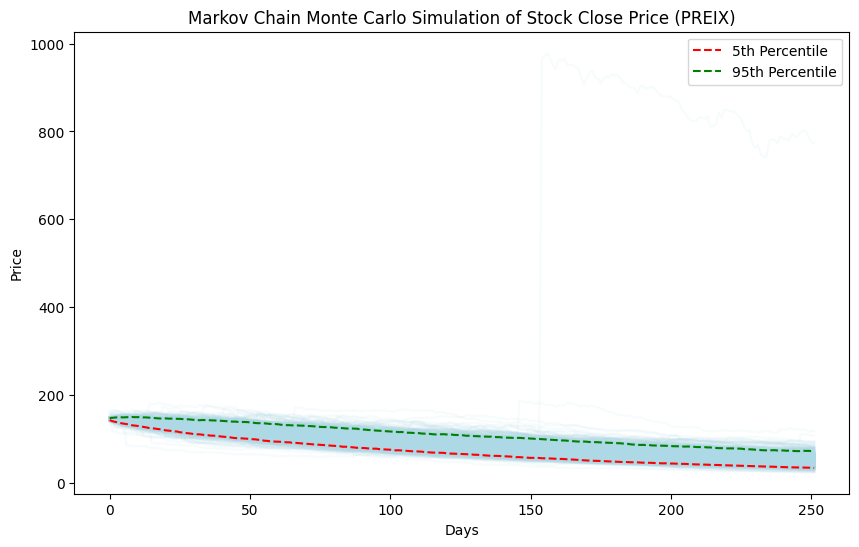

In [12]:
#mc sim

# Fit the Student's t distribution to the returns data
params = t.fit(stock_data['Daily Return'].dropna())

# Get the parameters of the distribution
df_t, mu, sigma = params

# from above
print("Transition Matrix:\n", transition_matrix)
initial_price = stock_data['Close'].iloc[-1]  # Initial stock price
states = ["Up", "Down", "Stagnant"] #reexammine this definition here

# 4. Monte Carlo Simulation based on Markov Chain
n_simulations = 1000  # Number of simulation paths
n_days = 252  # Simulate for 1 year (252 trading days)

# Initial state probabilities
initial_state = stock_data['Markov State'].iloc[-1]
initial_state_probabilities = [1 if state == initial_state else 0 for state in states]

# Simulating the paths
simulated_paths = []
for sim in range(n_simulations):
    simulated_returns = []
    current_state = np.random.choice(states, p=initial_state_probabilities)
    
    for day in range(n_days):
        # Simulate return based on the current state using Student's t-distribution
        if current_state == "Up":
            daily_return = t.rvs(df_t, loc=mu + sigma, scale=sigma)
        elif current_state == "Down":
            daily_return = t.rvs(df_t, loc=mu - sigma, scale=sigma)
        else:
            daily_return = t.rvs(df_t, loc=mu, scale=sigma)
        
        simulated_returns.append(daily_return)
        # Transition to the next state based on the transition matrix
        #current_state = np.random.choice(states, p=transition_matrix.loc[current_state].values)
        
        today_features_df = pd.DataFrame([transDet.iloc[-1][features].values], columns=features)
        x_today = scaler.transform(today_features_df)
        probs = transition_models[current_state].predict_proba(x_today)[0]
        next_state = np.random.choice(states, p=probs)
        current_state = next_state

    
    # Cumulative price based on returns
    simulated_prices = initial_price * np.exp(np.cumsum(simulated_returns))
    simulated_paths.append(simulated_prices)

# Convert the list of paths to a DataFrame
simulated_paths_df = pd.DataFrame(simulated_paths).T

# 5. Plotting the Monte Carlo simulation
plt.figure(figsize=(10, 6))
plt.plot(simulated_paths_df, color="lightblue", alpha=0.1)

# Add 5% and 95% percentile lines
percentiles_5 = simulated_paths_df.quantile(0.05, axis=1)
percentiles_95 = simulated_paths_df.quantile(0.95, axis=1)

plt.plot(percentiles_5, color="red", linestyle="--", label="5th Percentile")
plt.plot(percentiles_95, color="green", linestyle="--", label="95th Percentile")

# Add labels and title
ticker = "PREIX" #demo ticker remember
plt.title(f"Markov Chain Monte Carlo Simulation of Stock Close Price ({ticker})")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()


In [13]:
#mc extra adds

# 6. Computing VaR (Value at Risk)
final_prices = simulated_paths_df.iloc[-1]
losses = initial_price - final_prices
confidence_level = 0.95

# VaR at 95% confidence level
var_95 = np.percentile(losses, (1 - confidence_level) * 100)
print(f"Value at Risk (VaR) at 95% confidence level: {var_95:.2f}")

# 7. Computing Confidence Intervals
mean_final_price = np.mean(final_prices)
std_final_price = np.std(final_prices)
ci_95 = norm.interval(0.95, loc=mean_final_price, scale=std_final_price)

print(f"95% Confidence Interval for the final price: {ci_95}")

Value at Risk (VaR) at 95% confidence level: 73.74
95% Confidence Interval for the final price: (np.float64(1.6070623688006336), np.float64(102.26048119362454))


In [14]:
stock_data

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,Daily Return,Markov State,Prev State
Date,,,,,,,,,,,
2000-01-03 00:00:00-05:00,23.963501,23.963501,23.963501,23.963501,0,0.00,0.0,0.0,NaN,Stagnant,None
2000-01-04 00:00:00-05:00,23.046051,23.046051,23.046051,23.046051,0,0.00,0.0,0.0,-0.038285,Down,Stagnant
2000-01-05 00:00:00-05:00,23.094992,23.094992,23.094992,23.094992,0,0.00,0.0,0.0,0.002124,Stagnant,Down
2000-01-06 00:00:00-05:00,23.119461,23.119461,23.119461,23.119461,0,0.00,0.0,0.0,0.001060,Stagnant,Stagnant
2000-01-07 00:00:00-05:00,23.749439,23.749439,23.749439,23.749439,0,0.00,0.0,0.0,0.027249,Up,Stagnant
...,...,...,...,...,...,...,...,...,...,...,...
2024-09-24 00:00:00-04:00,144.706223,144.706223,144.706223,144.706223,0,0.00,0.0,0.0,0.002520,Stagnant,Stagnant
2024-09-25 00:00:00-04:00,144.438187,144.438187,144.438187,144.438187,0,0.00,0.0,0.0,-0.001852,Stagnant,Stagnant
2024-09-26 00:00:00-04:00,145.033325,145.033325,145.033325,145.033325,0,0.42,0.0,0.0,0.004120,Stagnant,Stagnant
